Scrambled Image:


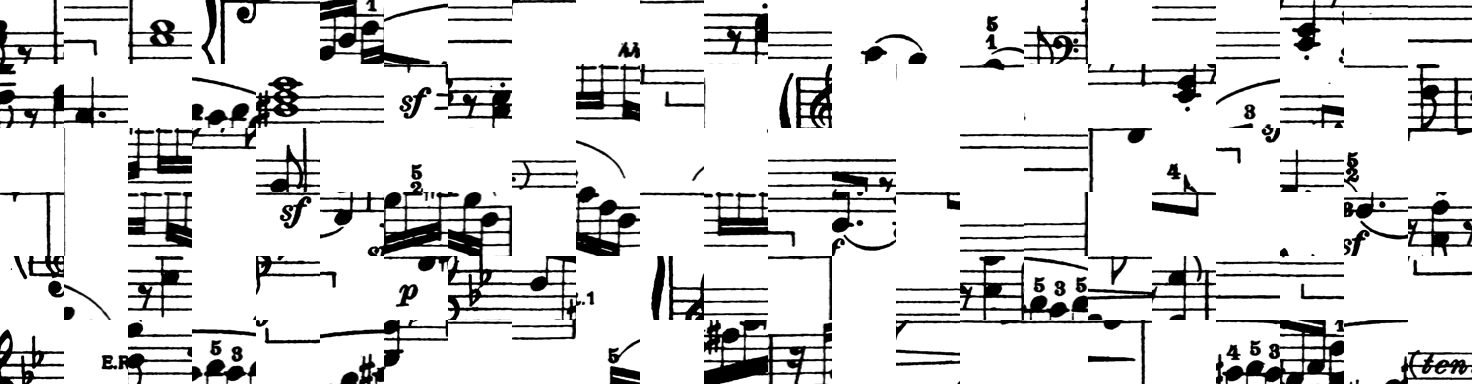

In [278]:
# I tried multiple ways but adding only this file as this gives the best output.


import numpy as np
from PIL import Image
from IPython.display import display

def load_scrambled_image(image_path, tile_size):

    img = Image.open(image_path).convert("L")  # Convert to grayscale
    width, height = img.size

    tiles = []
    positions = []  # Store tile positions (x, y)

    for y in range(0, height, tile_size):
        for x in range(0, width, tile_size):
            tile = img.crop((x, y, x + tile_size, y + tile_size))
            tiles.append(tile)
            positions.append((x, y))  # Store tile coordinates

    return img, tiles, positions


scrambled_image_path = "music2_scr64.png"  #  scrambled64 music2_scr64 music2_100
tile_size = 64
scrambled_img, tiles, tile_positions = load_scrambled_image(scrambled_image_path, tile_size)


print("Scrambled Image:")
display(scrambled_img)

Displaying tile at position (0, 0):


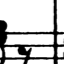

In [279]:

def display_specific_tile(tiles, tile_positions, target_position):
    """
    Display a specific tile given its position in the scrambled image.
    """
    if target_position in tile_positions:
        index = tile_positions.index(target_position)
        selected_tile = tiles[index]
        print(f"Displaying tile at position {target_position}:")
        display(selected_tile)
    else:
        print(f"Error: Tile at position {target_position} not found!")


specific_tile_position = (0, 0)  # Replace with your desired (x, y) position


display_specific_tile(tiles, tile_positions, specific_tile_position)

Template Image:


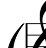

In [280]:

def load_template(template_path):

    template = Image.open(template_path).convert("L")
    print("Template Image:")
    display(template)
    
    return template

# Load the template (G-clef part)
template_image_path = "new/temp/t3.png"   # Replace with your template
template_img = load_template(template_image_path)



In [281]:

def binarize_image(img, threshold=128):

    img_arr = np.array(img, dtype=np.uint8)
    bin_img = (img_arr < threshold).astype(np.uint8)  # Black areas become 1, white areas become 0
    return bin_img

# Convert both tiles and template to binary images
template_bin = binarize_image(template_img)


In [282]:

def corr_cross_black(m_arr, t_arr):

    H, W = m_arr.shape
    hT, wT = t_arr.shape

    score_map = np.zeros((H - hT + 1, W - wT + 1))  # Ensure valid range
    
    for r in range(H - hT + 1):
        for c in range(W - wT + 1):
            region = m_arr[r:r+hT, c:c+wT]
            score_map[r, c] = np.sum(region * t_arr)  # Sum only where template is black (1s)

    return score_map
    

In [283]:

def find_top_matching_tiles(tiles, tile_positions, template_bin, top_n=10):
    """
    Compare each tile with the template and return the top N best-matching tiles.
    """
    match_results = []  # Store (score, tile, position)

    for idx, tile in enumerate(tiles):
        tile_bin = binarize_image(tile)  # Convert tile to binary
        score_map = corr_cross_black(tile_bin, template_bin)  # Match only black regions
        max_score = np.max(score_map)  # Get highest similarity score

        match_results.append((max_score, tile, tile_positions[idx]))  # Store (score, tile, position)


    match_results.sort(reverse=True, key=lambda x: x[0])


    return match_results[:top_n]


Top 10 Best-Matching Tiles (Using Only Black Areas):
1. Position: (768, 64), Score: 283.0
2. Position: (384, 192), Score: 253.0
3. Position: (704, 320), Score: 252.0
4. Position: (448, 64), Score: 248.0
5. Position: (576, 192), Score: 243.0
6. Position: (256, 128), Score: 235.0
7. Position: (192, 320), Score: 227.0
8. Position: (704, 0), Score: 226.0
9. Position: (1280, 320), Score: 224.0
10. Position: (320, 0), Score: 223.0

Displaying Top 10 Matches:
Tile at (768, 64):


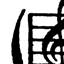

Tile at (384, 192):


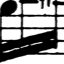

Tile at (704, 320):


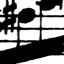

Tile at (448, 64):


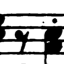

Tile at (576, 192):


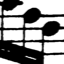

Tile at (256, 128):


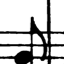

Tile at (192, 320):


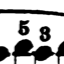

Tile at (704, 0):


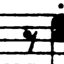

Tile at (1280, 320):


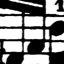

Tile at (320, 0):


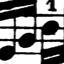

In [284]:

top_matches = find_top_matching_tiles(tiles, tile_positions, template_bin, top_n=10)


print("Top 10 Best-Matching Tiles (Using Only Black Areas):")
for rank, (score, _, position) in enumerate(top_matches, start=1):
    print(f"{rank}. Position: {position}, Score: {score}")


print("\nDisplaying Top 10 Matches:")
for _, tile, position in top_matches:
    print(f"Tile at {position}:")
    display(tile)

Scrambled Image:


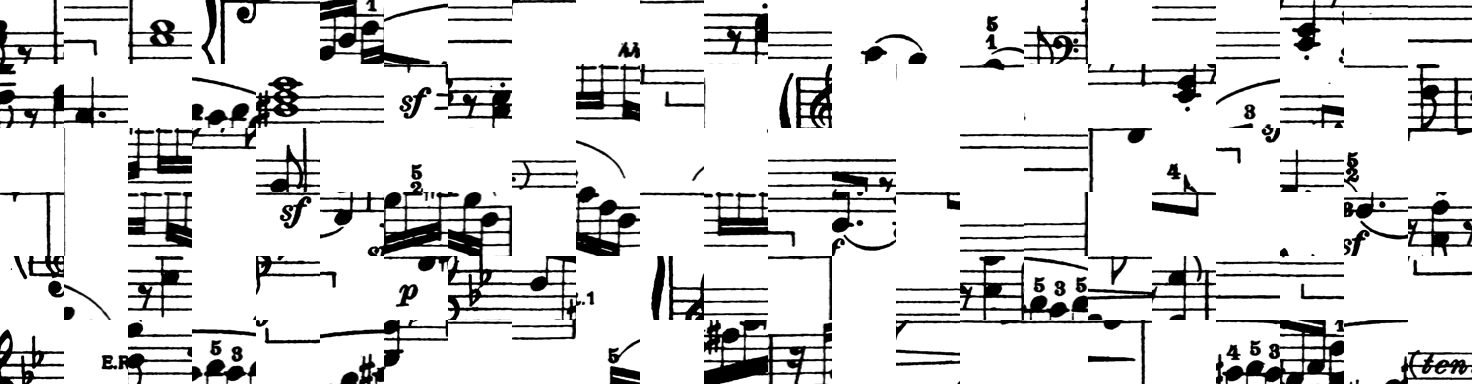

Template Image:


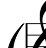

Top 10 Best-Matching Tiles (Using Only Black Areas):
1. Position: (768, 64), Score: 283.0
2. Position: (384, 192), Score: 253.0
3. Position: (704, 320), Score: 252.0
4. Position: (448, 64), Score: 248.0
5. Position: (576, 192), Score: 243.0
6. Position: (256, 128), Score: 235.0
7. Position: (192, 320), Score: 227.0
8. Position: (704, 0), Score: 226.0
9. Position: (1280, 320), Score: 224.0
10. Position: (320, 0), Score: 223.0

Displaying Top Match:
Best Match at (768, 64):


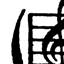

In [326]:
import numpy as np
from PIL import Image
from IPython.display import display

def load_scrambled_image(image_path, tile_size):
    
    img = Image.open(image_path).convert("L")  # Convert to grayscale
    width, height = img.size

    tiles = []
    positions = []  # Store tile positions (x, y)

    for y in range(0, height, tile_size):
        for x in range(0, width, tile_size):
            tile = img.crop((x, y, x + tile_size, y + tile_size))
            tiles.append(tile)
            positions.append((x, y))  # Store tile coordinates

    return img, tiles, positions

def load_template(template_path):

    template = Image.open(template_path).convert("L")
    print("Template Image:")
    display(template)
    return template

def binarize_image(img, threshold=128):

    img_arr = np.array(img, dtype=np.uint8)
    return (img_arr < threshold).astype(np.uint8)  # Black areas become 1, white areas become 0

def corr_cross_black(m_arr, t_arr):

    H, W = m_arr.shape
    hT, wT = t_arr.shape

    score_map = np.zeros((H - hT + 1, W - wT + 1))  # Ensure valid range

    for r in range(H - hT + 1):
        for c in range(W - wT + 1):
            region = m_arr[r:r+hT, c:c+wT]
            score_map[r, c] = np.sum(region * t_arr)  # Sum only where template is black (1s)

    return score_map

def find_top_matching_tiles(tiles, tile_positions, template_bin, top_n=10):

    match_results = []  # Store (score, tile, position)

    for idx, tile in enumerate(tiles):
        tile_bin = binarize_image(tile)  # Convert tile to binary
        score_map = corr_cross_black(tile_bin, template_bin)  # Match only black regions
        max_score = np.max(score_map)  # Get highest similarity score

        match_results.append((max_score, tile, tile_positions[idx]))  # Store (score, tile, position)

    # Sort results by score (descending order)
    match_results.sort(reverse=True, key=lambda x: x[0])


    return match_results[:top_n]

def main(scrambled_image_path, template_image_path, tile_size, top_n):

    scrambled_img, tiles, tile_positions = load_scrambled_image(scrambled_image_path, tile_size)

    print("Scrambled Image:")
    display(scrambled_img)


    template_img = load_template(template_image_path)


    template_bin = binarize_image(template_img)


    top_matches = find_top_matching_tiles(tiles, tile_positions, template_bin, top_n=top_n)


    print("Top 10 Best-Matching Tiles (Using Only Black Areas):")
    for rank, (score, _, position) in enumerate(top_matches, start=1):
        print(f"{rank}. Position: {position}, Score: {score}")

    print("\nDisplaying Top Match:")
    if top_matches:
        _, best_tile, best_position = top_matches[0]
        print(f"Best Match at {best_position}:")
        display(best_tile)

if __name__ == "__main__":
    scrambled_image_path = "music2_scr64.png"  #
    template_image_path = "new/temp/t3.png"   # 
    tile_size=64
    top_n = 10
    main(scrambled_image_path, template_image_path,tile_size,top_n)


# ======================================================

In [298]:
import numpy as np
from PIL import Image
from IPython.display import display

Original Image:


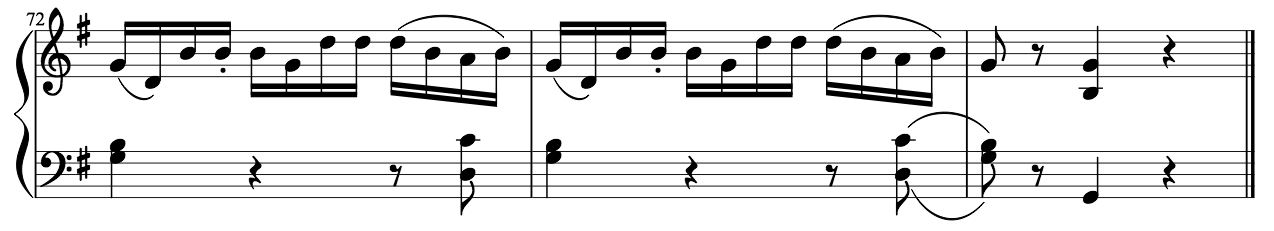

Scrambled Image:


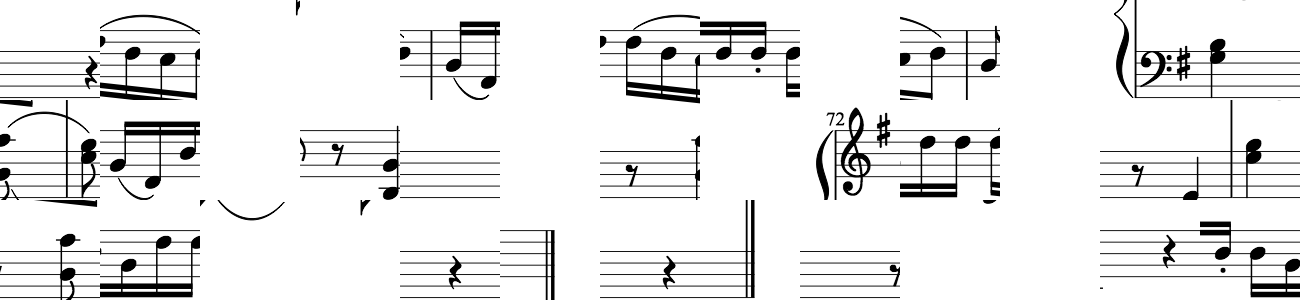

In [314]:

def load_images():
    """Load original and scrambled images"""
    original = Image.open("music1.png").convert("L")  # Convert to grayscale
    scrambled = Image.open("music1_100.png").convert("L")  # Convert to grayscale
    
    print("Original Image:")
    display(original)
    print("Scrambled Image:")
    display(scrambled)
    
    return original, scrambled

# Load images
orig_img, scram_img = load_images()

Tile Structure:


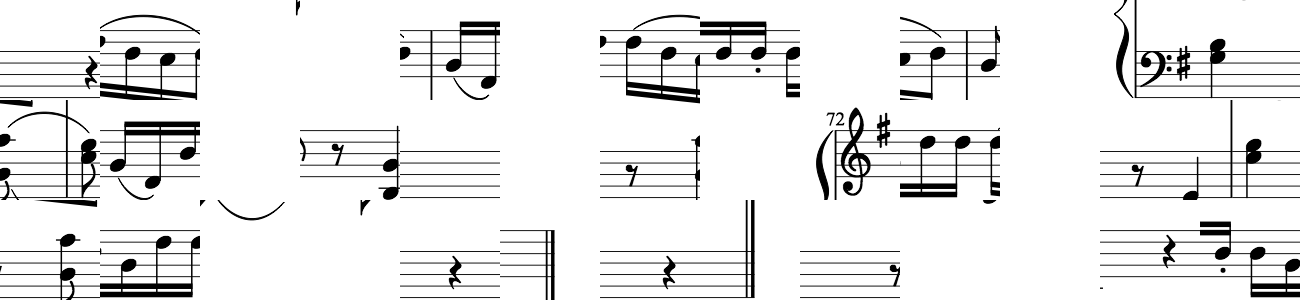

In [315]:

def show_tile_structure(img, tile_size):

    width, height = img.size
    tiles = []
    positions = []  # Store tile positions

    for y in range(0, height, tile_size):
        for x in range(0, width, tile_size):
            tile = img.crop((x, y, x + tile_size, y + tile_size))
            tiles.append(tile)
            positions.append((x, y))

    print("Tile Structure:")
    display(img)
    
    return tiles, positions

# Define tile size
tile_size = 100  
tiles, positions = show_tile_structure(scram_img, tile_size)

In [316]:

def compare_staff_edges(tile1, tile2, direction='right'):
    """Compare edges for staff line continuity"""
    if direction == 'right':
        edge1 = tile1.crop((tile1.width-2, 0, tile1.width, tile1.height))
        edge2 = tile2.crop((0, 0, 2, tile2.height))
    else:  # bottom
        edge1 = tile1.crop((0, tile1.height-2, tile1.width, tile1.height))
        edge2 = tile2.crop((0, 0, tile2.width, 2))

    diff = sum(abs(p1 - p2) for p1, p2 in zip(edge1.getdata(), edge2.getdata()))
    return diff

In [317]:

def load_template(template_path):

    template = Image.open(template_path).convert("L")
    print("Template Image:")
    display(template)
    return template

def binarize_image(img, threshold=128):

    img_arr = np.array(img, dtype=np.uint8)
    return (img_arr < threshold).astype(np.uint8)  # Black areas become 1

def corr_cross_black(m_arr, t_arr):

    H, W = m_arr.shape
    hT, wT = t_arr.shape
    score_map = np.zeros((H - hT + 1, W - wT + 1))

    for r in range(H - hT + 1):
        for c in range(W - wT + 1):
            region = m_arr[r:r+hT, c:c+wT]
            score_map[r, c] = np.sum(region * t_arr)

    return score_map

In [318]:
def find_top_matching_tiles(tiles, tile_positions, template_bin, top_n=10):

    match_results = []

    for idx, tile in enumerate(tiles):
        tile_bin = binarize_image(tile)
        score_map = corr_cross_black(tile_bin, template_bin)
        max_score = np.max(score_map)
        match_results.append((max_score, tile, tile_positions[idx]))

    match_results.sort(reverse=True, key=lambda x: x[0])
    return match_results[:top_n]

Template Image:


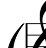

Fixed Top-Left Tile at Position: (800, 100)


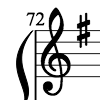

In [319]:

template_path = "new/temp/t3.png"  
template_img = load_template(template_path)
template_bin = binarize_image(template_img)

top_matches = find_top_matching_tiles(tiles, positions, template_bin, top_n=1)
top_left_tile, top_left_position = top_matches[0][1], top_matches[0][2]
print(f"Fixed Top-Left Tile at Position: {top_left_position}")
display(top_left_tile)

In [320]:

def build_first_row(tiles, positions, fixed_tile, fixed_position, tile_size):

    width = scram_img.width
    remaining_tiles = tiles.copy()
    remaining_positions = positions.copy()

    # Fix the first tile in place
    current_row = [fixed_tile]
    remaining_tiles.remove(fixed_tile)
    remaining_positions.remove(fixed_position)

    print("Building First Row:")
    while len(current_row) < width // tile_size:
        best_score = float('inf')
        best_tile = None

        for tile in remaining_tiles:
            score = compare_staff_edges(current_row[-1], tile, 'right')
            if score < best_score:
                best_score = score
                best_tile = tile

        current_row.append(best_tile)
        remaining_tiles.remove(best_tile)

        # Show partial reconstruction
        partial = Image.new('L', (len(current_row)*tile_size, tile_size))
        for i, t in enumerate(current_row):
            partial.paste(t, (i*tile_size, 0))
        display(partial)

    return current_row, remaining_tiles

Building First Row:


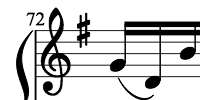

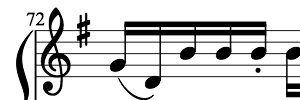

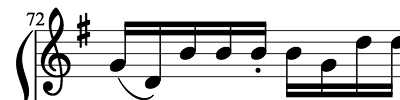

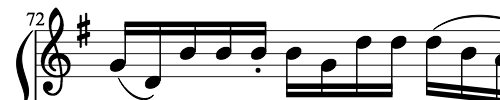

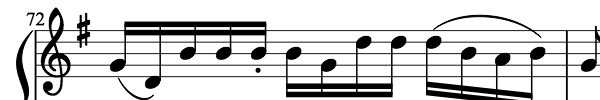

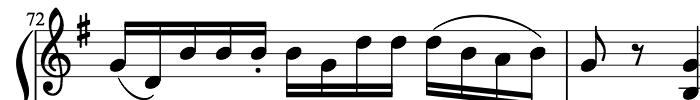

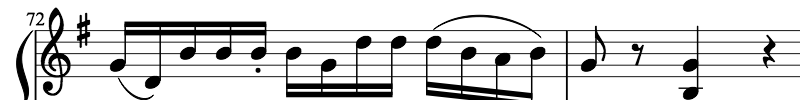

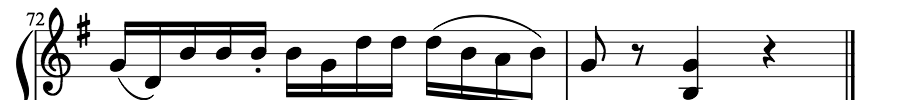

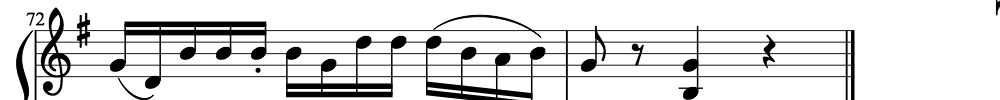

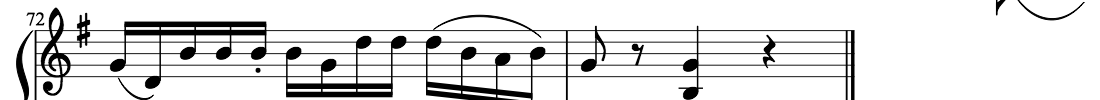

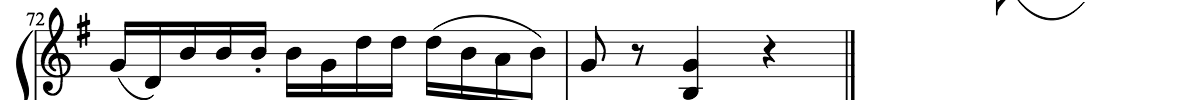

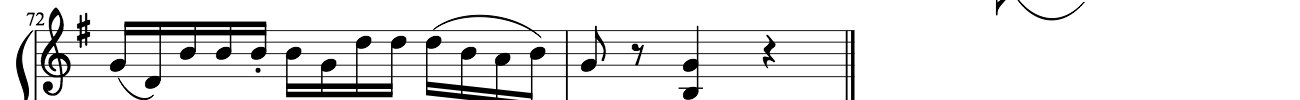

In [321]:
first_row, remaining_tiles = build_first_row(tiles, positions, top_left_tile, top_left_position, tile_size)


In [322]:

def build_full_grid(first_row, remaining_tiles, tile_size):
    """Build complete grid using staff line continuity"""
    grid = [first_row]
    total_rows = scram_img.height // tile_size

    print("Building Complete Grid:")
    for row_num in range(1, total_rows):
        current_row = []
        for col_num in range(len(first_row)):
            best_score = float('inf')
            best_tile = None

            for tile in remaining_tiles:
                score = compare_staff_edges(grid[row_num-1][col_num], tile, 'bottom')
                if score < best_score:
                    best_score = score
                    best_tile = tile

            current_row.append(best_tile)
            remaining_tiles.remove(best_tile)

        grid.append(current_row)

        # Show partial reconstruction
        partial = Image.new('L', (scram_img.width, (row_num+1)*tile_size))
        for r in range(row_num+1):
            for c in range(len(grid[r])):
                partial.paste(grid[r][c], (c*tile_size, r*tile_size))
        display(partial)

    return grid


Building Complete Grid:


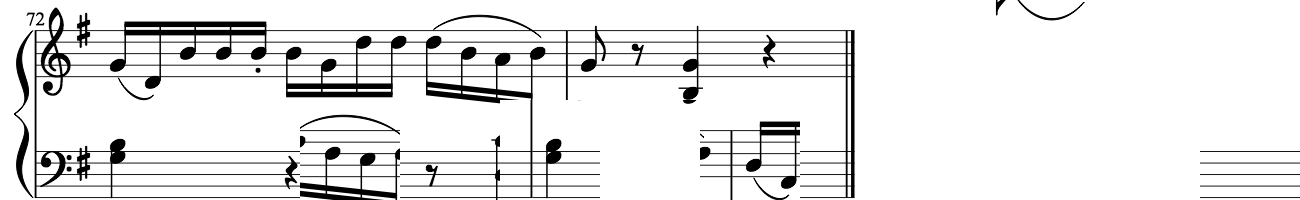

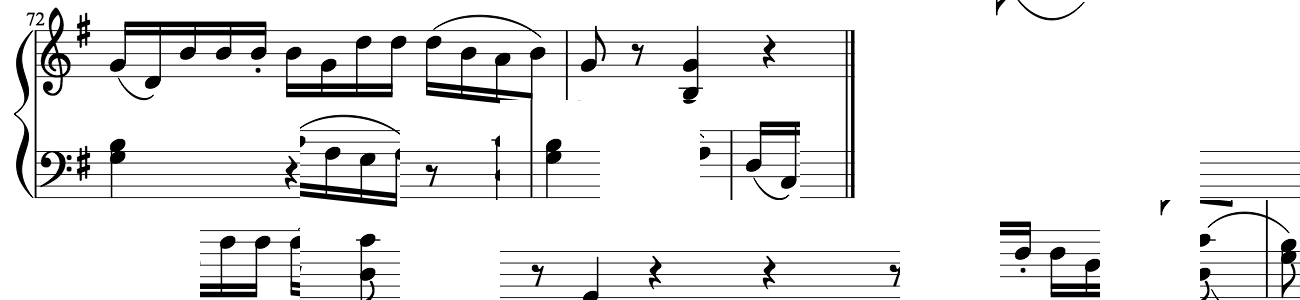

In [323]:
full_grid = build_full_grid(first_row, remaining_tiles, tile_size)

Final Reconstruction:


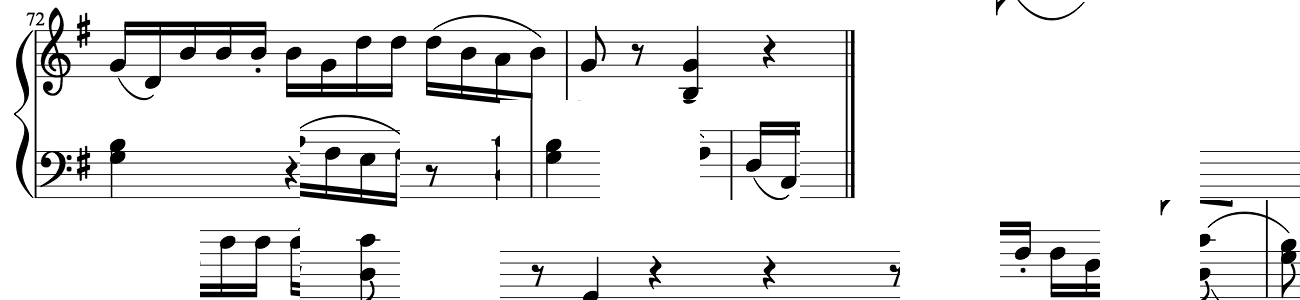

In [324]:

def final_reconstruction(grid, tile_size):

    reconstructed = Image.new('L', scram_img.size)

    for row_idx, row in enumerate(grid):
        reversed_row = row[::-1]
        for col_idx, tile in enumerate(reversed_row):
            x = (len(row) - 1 - col_idx) * tile_size
            y = row_idx * tile_size
            reconstructed.paste(tile, (x, y))

    print("Final Reconstruction:")
    display(reconstructed)
    return reconstructed

final_img = final_reconstruction(full_grid, tile_size)

Scrambled Image:


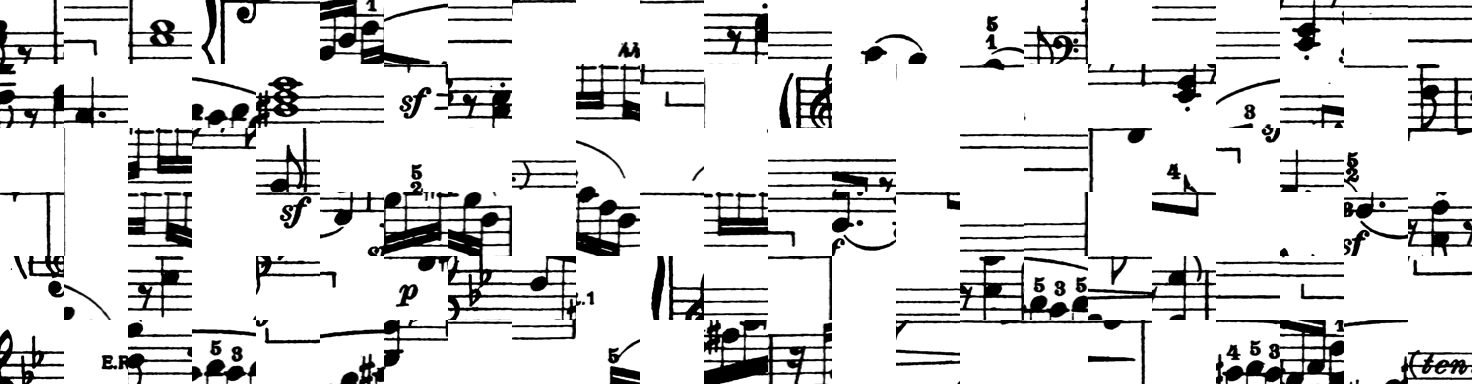

Template Image:


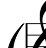

Best Matching Tile:
Position: (768, 64), Score: 283.0


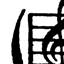

In [1]:
import numpy as np
from PIL import Image
from IPython.display import display

def load_scrambled_image(image_path, tile_size):
    img = Image.open(image_path).convert("L")  # Convert to grayscale
    width, height = img.size

    tiles = []
    positions = []  # Store tile positions (x, y)

    for y in range(0, height, tile_size):
        for x in range(0, width, tile_size):
            tile = img.crop((x, y, x + tile_size, y + tile_size))
            tiles.append(tile)
            positions.append((x, y))  # Store tile coordinates

    return img, tiles, positions

def load_template(template_path):
    template = Image.open(template_path).convert("L")
    print("Template Image:")
    display(template)
    return template

def binarize_image(img, threshold=128):
    img_arr = np.array(img, dtype=np.uint8)
    return (img_arr < threshold).astype(np.uint8)  # Black areas become 1, white areas become 0

def corr_cross_black(m_arr, t_arr):
    H, W = m_arr.shape
    hT, wT = t_arr.shape

    score_map = np.zeros((H - hT + 1, W - wT + 1))  # Ensure valid range

    for r in range(H - hT + 1):
        for c in range(W - wT + 1):
            region = m_arr[r:r+hT, c:c+wT]
            score_map[r, c] = np.sum(region * t_arr)  # Sum only where template is black (1s)

    return score_map

def find_top_matching_tile(tiles, tile_positions, template_bin):
    best_tile = None
    best_position = None
    best_score = -np.inf

    for idx, tile in enumerate(tiles):
        tile_bin = binarize_image(tile)  # Convert tile to binary
        score_map = corr_cross_black(tile_bin, template_bin)  # Match only black regions
        max_score = np.max(score_map)  # Get highest similarity score

        if max_score > best_score:
            best_score = max_score
            best_tile = tile
            best_position = tile_positions[idx]

    return best_tile, best_position, best_score

def main(scrambled_image_path, template_image_path, tile_size):

    scrambled_img, tiles, tile_positions = load_scrambled_image(scrambled_image_path, tile_size)
    print("Scrambled Image:")
    display(scrambled_img)


    template_img = load_template(template_image_path)
    template_bin = binarize_image(template_img)


    best_tile, best_position, best_score = find_top_matching_tile(tiles, tile_positions, template_bin)
    
    print("Best Matching Tile:")
    print(f"Position: {best_position}, Score: {best_score}")
    display(best_tile)
    

    return best_tile, best_position, best_score

if __name__ == "__main__":
    scrambled_image_path = "music2_scr64.png"  
    template_image_path = "new/temp/t3.png"      
    tile_size = 64
    best_tile, best_position, best_score = main(scrambled_image_path, template_image_path, tile_size)


Scrambled Image:


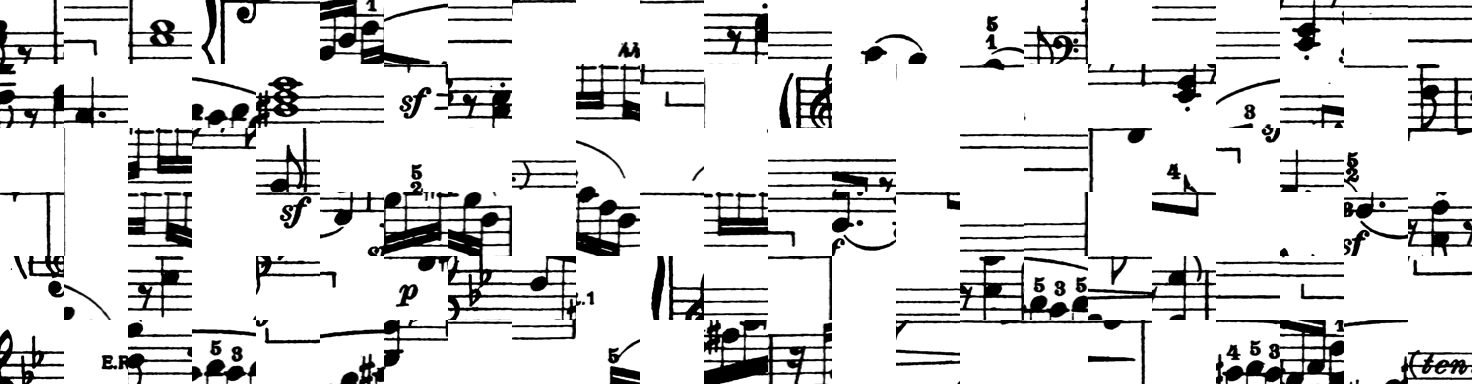

Template Image:


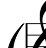

Best Top-Left Tile found at (768, 64) with Score: 283.0


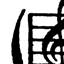

In [4]:
import numpy as np
from PIL import Image
from IPython.display import display

def load_scrambled_image(image_path, tile_size):

    img = Image.open(image_path).convert("L")  # Convert to grayscale
    width, height = img.size

    tiles = []
    positions = []  # Store tile positions (x, y)

    for y in range(0, height, tile_size):
        for x in range(0, width, tile_size):
            tile = img.crop((x, y, x + tile_size, y + tile_size))
            tiles.append(tile)
            positions.append((x, y))  # Store tile coordinates

    return img, tiles, positions

def load_template(template_path):

    template = Image.open(template_path).convert("L")
    print("Template Image:")
    display(template)
    return template

def binarize_image(img, threshold=128):

    img_arr = np.array(img, dtype=np.uint8)
    return (img_arr < threshold).astype(np.uint8)

def corr_cross_black(m_arr, t_arr):

    H, W = m_arr.shape
    hT, wT = t_arr.shape

    score_map = np.zeros((H - hT + 1, W - wT + 1))  # Ensure valid range

    for r in range(H - hT + 1):
        for c in range(W - wT + 1):
            region = m_arr[r:r+hT, c:c+wT]
            score_map[r, c] = np.sum(region * t_arr)  # Only sum where template is black

    return score_map

def find_top_matching_tile(tiles, positions, template_bin):

    best_tile = None
    best_position = None
    best_score = -np.inf

    for idx, tile in enumerate(tiles):
        tile_bin = binarize_image(tile)
        score_map = corr_cross_black(tile_bin, template_bin)
        max_score = np.max(score_map)
        if max_score > best_score:
            best_score = max_score
            best_tile = tile
            best_position = positions[idx]

    return best_tile, best_position, best_score

def main(scrambled_image_path, template_image_path, tile_size):

    scrambled_img, tiles, positions = load_scrambled_image(scrambled_image_path, tile_size)
    print("Scrambled Image:")
    display(scrambled_img)


    template_img = load_template(template_image_path)
    template_bin = binarize_image(template_img)


    best_tile, best_position, best_score = find_top_matching_tile(tiles, positions, template_bin)
    print(f"Best Top-Left Tile found at {best_position} with Score: {best_score}")
    display(best_tile)

 
    best_top_left_tile = (best_tile, best_position, best_score)
    return best_top_left_tile

if __name__ == "__main__":
    scrambled_image_path = "music2_scr64.png" 
    template_image_path = "new/temp/t3.png"    
    tile_size = 64

    best_top_left_tile = main(scrambled_image_path, template_image_path, tile_size)
